In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv("materials_clean.csv")
print(f"loaded {len(df)} clean materials")

loaded 20258 clean materials


In [2]:
from pymatgen.core import Composition
def to_composition(formula):
    try:
        return Composition(formula)
    except:
        return None

df['composition']=df['formula'].apply(to_composition) 
df=df.dropna(subset=['composition']) 
print(f"Compositions ready: {len(df)}")

Compositions ready: 20258


In [3]:
from matminer.featurizers.composition import ElementProperty
featurizer = ElementProperty.from_preset("magpie")
print(f"Features to generate: {len(featurizer.feature_labels())}")
print("Running... this takes a few minutes")
df=featurizer.featurize_dataframe(
    df,
    col_id='composition',
    ignore_errors=True)
print(f"Done , Shape: {df.shape}")

Features to generate: 132
Running... this takes a few minutes


ElementProperty:   0%|          | 0/20258 [00:00<?, ?it/s]

Done , Shape: (20258, 144)


In [16]:
feature_cols=featurizer.feature_labels() 
X=df[feature_cols].copy()   
Y=df['bandgap'].copy()   
mask=X.notna().all(axis=1) 
X=X[mask] 
Y=Y[mask]  
print(f"X shape: {X.shape}") 
print(f"Y range: {Y.min():.2f} eV") 
X.to_csv("features_magpie.csv",index=False) 
Y.to_csv("targets_bandgap.csv",index=False) 


X shape: (20258, 132)
Y range: 0.50 eV


In [5]:
features_ready = X.copy()
features_ready['band_gap'] = Y
features_ready['formula'] = df.loc[X.index, 'formula']
features_ready['formation_energy'] = df.loc[X.index, 'formation_energy']

features_ready.to_csv("features_ready.csv", index=False)
print(f"Saved features_ready.csv — shape: {features_ready.shape}")

Saved features_ready.csv — shape: (20258, 135)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.dummy import DummyRegressor
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
baseline = DummyRegressor(strategy='mean') 
baseline.fit(X_train,Y_train) 
mae_baseline=mean_absolute_error(Y_test,baseline.predict(X_test)) 

print(f"Baseline MAE: {mae_baseline:.4f} eV")


Baseline MAE: 0.7072 eV


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train) 

X_test_scaled=scaler.transform(X_test) 
lr=LinearRegression()
lr.fit(X_train_scaled,Y_train)
mae_lr=mean_absolute_error(Y_test,lr.predict(X_test_scaled))

print(f"linear Regression MAE: {mae_lr:.4f} eV")

linear Regression MAE: 0.5919 eV


In [8]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1)
rf.fit(X_train,Y_train)
Y_pred_rf=rf.predict(X_test)
mae_rf=mean_absolute_error(Y_test,Y_pred_rf)
r2_rf=rf.score(X_test,Y_test)
print(f"Random Forest MAE: {mae_rf:.4f} eV")
print(f"Random Forest R²: {r2_rf:.4f}")


Random Forest MAE: 0.3874 eV
Random Forest R²: 0.6087


In [9]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")

print("Model saved!")

Model saved!


In [10]:
import joblib

feature_names = X.columns.tolist()

joblib.dump(feature_names, "feature_names.pkl")

print(f"Saved {len(feature_names)} feature names")

Saved 132 feature names


In [11]:
print(X.shape)
print(X.columns.tolist())

(20258, 132)
['MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber', 'MagpieData avg_dev MendeleevNumber', 'MagpieData mode MendeleevNumber', 'MagpieData minimum AtomicWeight', 'MagpieData maximum AtomicWeight', 'MagpieData range AtomicWeight', 'MagpieData mean AtomicWeight', 'MagpieData avg_dev AtomicWeight', 'MagpieData mode AtomicWeight', 'MagpieData minimum MeltingT', 'MagpieData maximum MeltingT', 'MagpieData range MeltingT', 'MagpieData mean MeltingT', 'MagpieData avg_dev MeltingT', 'MagpieData mode MeltingT', 'MagpieData minimum Column', 'MagpieData maximum Column', 'MagpieData range Column', 'MagpieData mean Column', 'MagpieData avg_dev Column', 'MagpieData mode Column', 'MagpieData minimum Row', 'MagpieData maximum Row', 'M

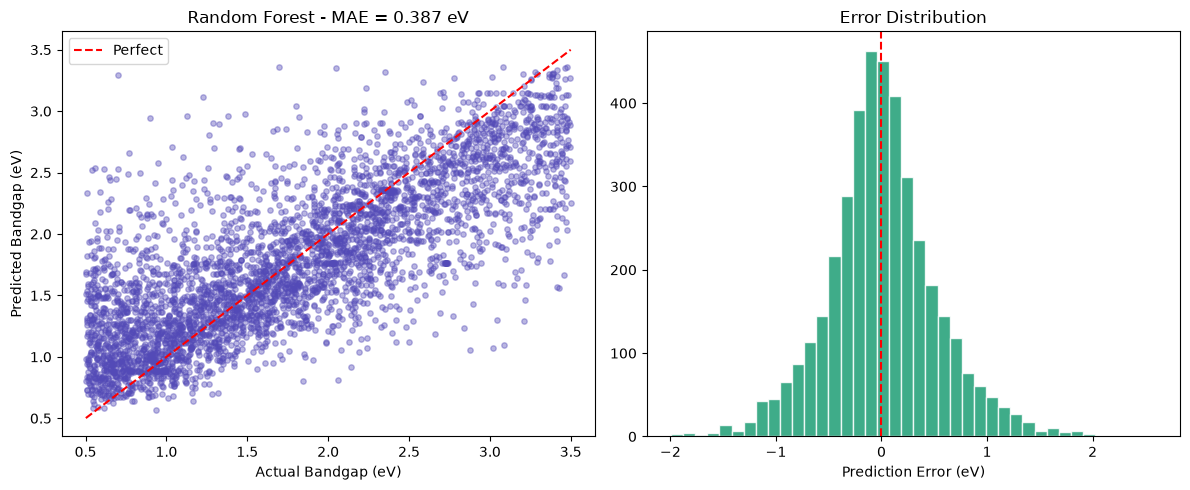

In [12]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
Y_test = Y_test.squeeze()
axes[0].scatter(Y_test,Y_pred_rf,alpha=0.4,s=15,color='#534AB7') 
lims=[min(Y_test.min(),Y_pred_rf.min()),max(Y_test.max(),Y_pred_rf.max())] 
axes[0].plot(lims,lims,'r--',linewidth=1.5,label='Perfect')
axes[0].set_xlabel('Actual Bandgap (eV)')
axes[0].set_ylabel('Predicted Bandgap (eV)')
axes[0].set_title(f'Random Forest - MAE = {mae_rf:.3f} eV')
axes[0].legend()

errors=Y_pred_rf - Y_test

axes[1].hist(errors,bins=40,color='#1D9E75',edgecolor='white',alpha=0.85)
axes[1].axvline(0,color='red',linestyle='--')
axes[1].set_xlabel('Prediction Error (eV)')
axes[1].set_title('Error Distribution')
plt.tight_layout() 
plt.savefig('day4_rf_result.png',dpi =150)
plt.show() 

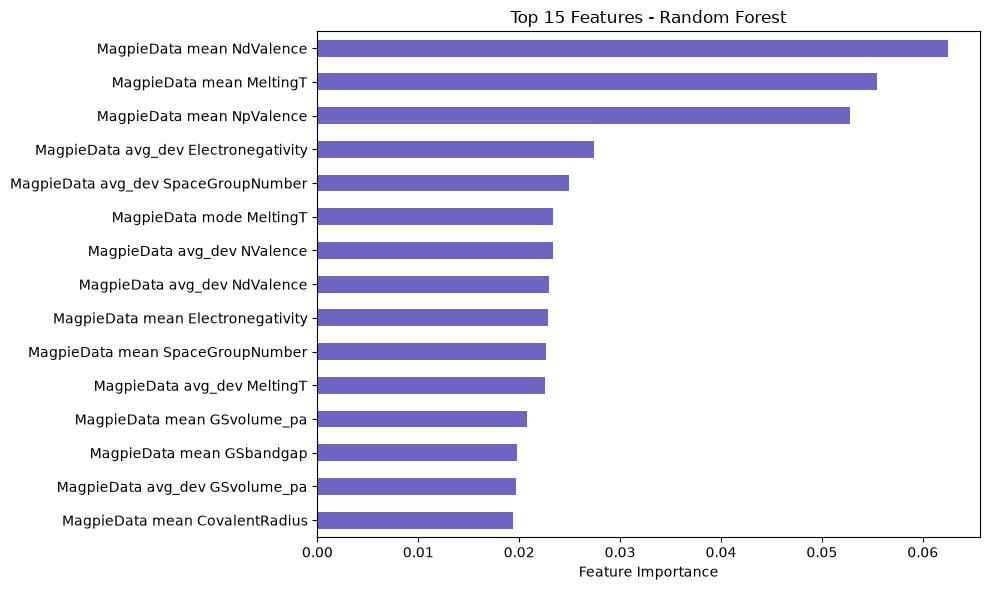

Top 5 features:
MagpieData mean NdValence               0.062543
MagpieData mean MeltingT                0.055511
MagpieData mean NpValence               0.052774
MagpieData avg_dev Electronegativity    0.027444
MagpieData avg_dev SpaceGroupNumber     0.024896
dtype: float64


In [13]:
importances=pd.Series(
    rf.feature_importances_,index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importances.head(15).plot(kind='barh',color='#534AB7',alpha=0.85)
plt.xlabel('Feature Importance')
plt.title('Top 15 Features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('day4_feature_importance.png',dpi=150)
plt.show()
print("Top 5 features:")
print(importances.head(5))

In [14]:
from sklearn.model_selection import cross_val_score
cv_scores=cross_val_score(
    RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1),
    X,Y,cv=5,
    scoring='neg_mean_absolute_error'
)
cv_mae=-cv_scores
print(f"MAE per fold: {cv_mae.round(4)}")
print(f"\n REPORTABLE RESULT : MAE ={cv_mae.mean():.3f} ± {cv_mae.std():.3f} eV <<<")


MAE per fold: [0.5267 0.4475 0.5307 0.4715 0.4828]

 REPORTABLE RESULT : MAE =0.492 ± 0.032 eV <<<


In [15]:
results=pd.DataFrame({
    'Model': ['Baseline','Linear Regression','Random Forest (5-CV)'],
    'MAE (eV)' : [round(mae_baseline,4),round(mae_lr,4),round(cv_mae.mean(),4)]
})
print(results.to_string(index=False))
results.to_csv("day4_results.csv",index=False)

               Model  MAE (eV)
            Baseline    0.7072
   Linear Regression    0.5919
Random Forest (5-CV)    0.4918
